In [35]:
import pandas as pd
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, opinion_lexicon
import string
from nltk.stem import PorterStemmer
from nltk.util import ngrams
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import numpy as np
import networkx as nx
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("netflix_reviews.csv")


In [36]:
df.columns

Index(['reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'appVersion'],
      dtype='str')

In [37]:
df = df.drop(columns = ['reviewId', 'userName', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'appVersion'])
df.columns

Index(['content', 'score'], dtype='str')

In [38]:
# making a sample of 10000 entries from the dataset
sample, _ = train_test_split(df, train_size = 10000, stratify = df['score'], random_state = 42)
sample.reset_index(drop = True, inplace = True)
sample['score'].value_counts()

score
1    3930
5    3173
4    1084
3     946
2     867
Name: count, dtype: int64

In [39]:
len(sample)

10000

In [40]:
# droping null values, removing punctuation, and converting to lowercase
sample = sample.dropna()
sample['content'] = sample['content'].str.replace(r"[^A-Za-z\s]", "", regex=True).str.lower()

In [41]:
len(sample)

9998

In [42]:
# no more null values
sample.isna().sum()

content    0
score      0
dtype: int64

In [43]:
# making a new column which has a list of all words in that row's content column and then dropping the content column
sample['content_tokenized'] = sample['content'].apply(word_tokenize) 
sample = sample.drop(columns = ['content'])

In [44]:
# defining set of stopwords
stop_words = set(stopwords.words('english'))

# defining function to remove stop words
def remove_stop(review):
    filtered = [word for word in review if word not in stop_words]
    return filtered

In [45]:
# removing stop words from content_tokenized column
sample['content_tokenized'] = sample['content_tokenized'].apply(remove_stop)

In [46]:
# making another column in sample with the words from the cleaned content column as strings
def into_string(content):
    return " ".join(content)

sample['content_string'] = sample['content_tokenized'].apply(into_string)

In [47]:
# swapping order of columns for improved readablility
sample = sample[['content_tokenized', 'content_string', 'score']]

In [48]:
sample.head(10)

,content_tokenized,content_string,score
0,"[used, netflix, years, mainly, low, pricing, g...",used netflix years mainly low pricing good sel...,1
1,"[playing, anything, huawei, p, pro, everytime,...",playing anything huawei p pro everytime video ...,1
2,"[new, update, stupid, dad, lives, different, s...",new update stupid dad lives different state us...,2
3,"[nice, app]",nice app,5
4,"[dont, know, download, movie, become, slowi, n...",dont know download movie become slowi need res...,3
5,"[love, neftlix, love, watch, movies, tv, dead,...",love neftlix love watch movies tv dead fun wat...,5
6,[good],good,5
7,"[lets, take, im, using, x, profile, showing, p...",lets take im using x profile showing profile l...,5
8,"[still, semi, regularly, hands, logo, paying, ...",still semi regularly hands logo paying content...,1
9,"[app, open, oneplus, pro, stuck, netflix, load...",app open oneplus pro stuck netflix loading scr...,1


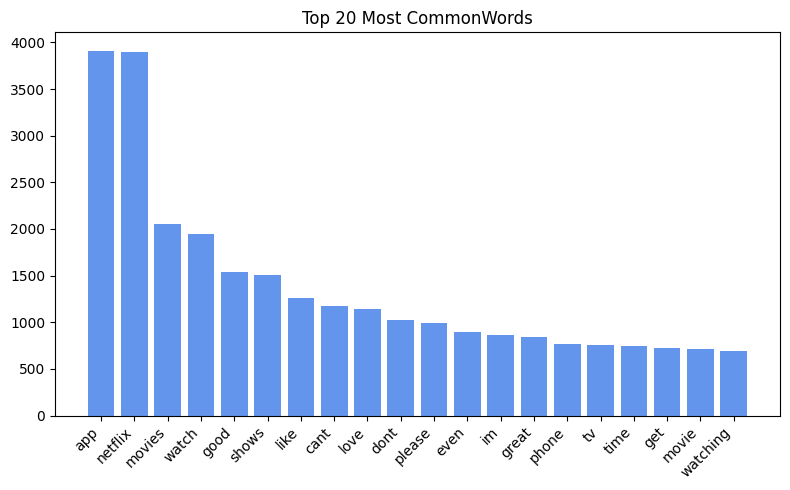

In [49]:
# bar chart for most common words
all_words = [w for tokens in sample['content_tokenized'] for w in tokens]
top_overall = Counter(all_words).most_common(20)

words, counts = zip(*top_overall)
plt.figure(figsize=(8, 5))
plt.bar(words, counts, color='cornflowerblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most CommonWords')
plt.tight_layout()
plt.show()

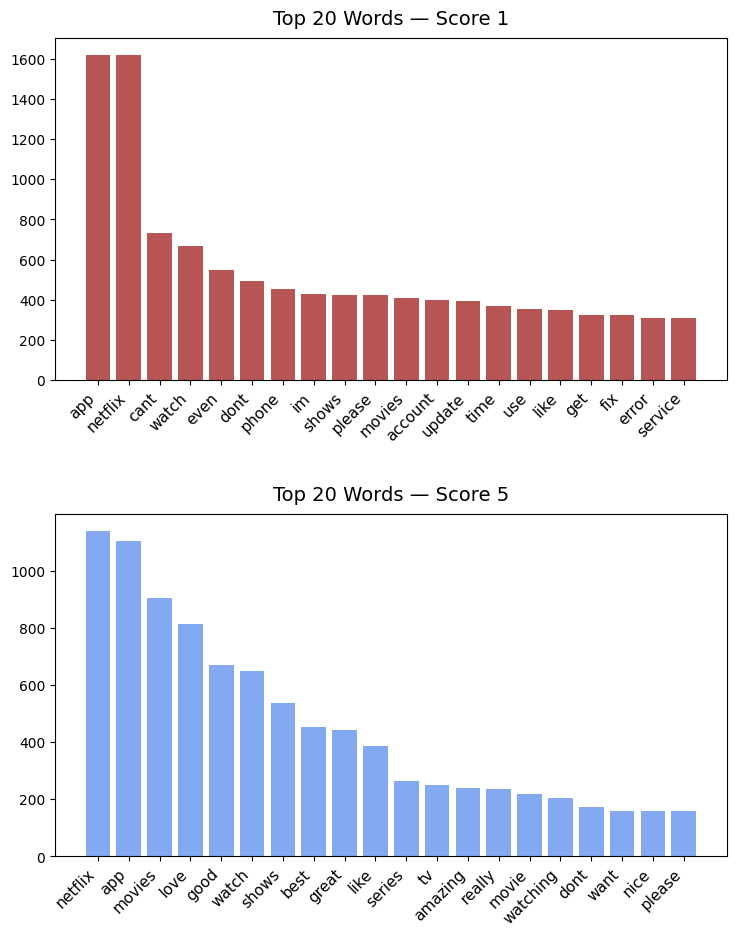

In [50]:
# bar chart for most common words of the highest and lowest scores
score_colors = {1: 'brown', 5: 'cornflowerblue'}

fig, axes = plt.subplots(2, 1, figsize=(8, 10))
for ax, score in zip(axes, [1, 5]):
    words_score = [
        w for tokens in sample[sample['score'] == score]['content_tokenized']
        for w in tokens
    ]
    top = Counter(words_score).most_common(20)
    w, c = zip(*top)
    ax.bar(w, c, color=score_colors[score], alpha=0.8)
    ax.set_title(f'Top 20 Words — Score {score}', fontsize=14, pad=10)
    ax.tick_params(axis='x', labelsize=11)
    ax.set_xticklabels(w, rotation=45, ha='right')
plt.tight_layout(pad=3.0)
plt.show()

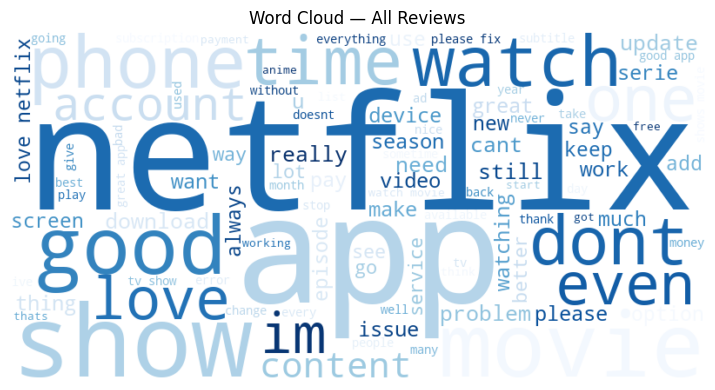

In [51]:
# word cloud for most common-occurring words
text_all = ' '.join(
    w for tokens in sample['content_tokenized']
    for w in tokens
)
wc = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Blues',
    max_words=100
).generate(text_all)

plt.figure(figsize=(8, 4))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Reviews')
plt.tight_layout()
plt.show()

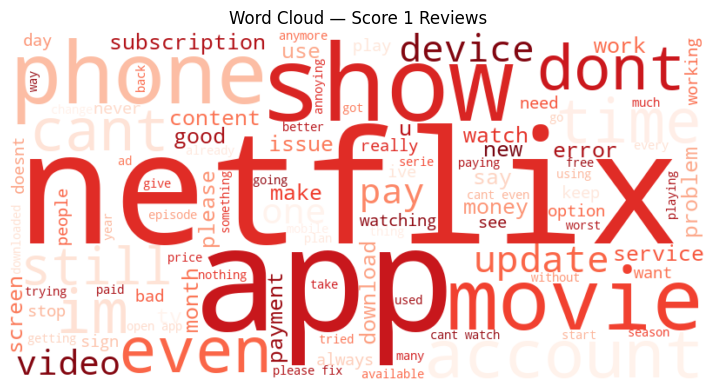

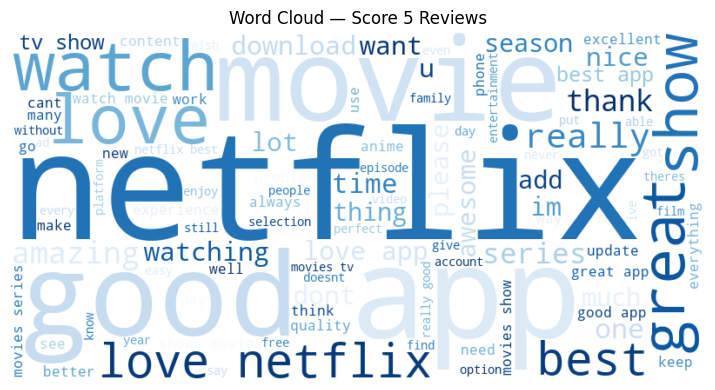

In [52]:
# word cloud for most common words of the highest and lowest scores
cloud_colormaps = {1: 'Reds', 5: 'Blues'}

for score in [1, 5]:
    text = ' '.join(
        w for tokens in sample[sample['score'] == score]['content_tokenized']
        for w in tokens
    )
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=cloud_colormaps[score],
        max_words=100
    ).generate(text)
    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud — Score {score} Reviews')
    plt.tight_layout()
    plt.savefig(f'wordcloud_score_{score}.png', dpi=150)
    plt.show()

In [53]:
# Calculate TF-IDF values for all words in the dataset
tfidf_vectorizer = TfidfVectorizer(max_features=None)  # Keep all features
tfidf_matrix = tfidf_vectorizer.fit_transform(sample['content_string'])

# Get feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Calculate mean TF-IDF values for each word across all documents
tfidf_mean = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

# Create a DataFrame with words and their mean TF-IDF values
tfidf_df = pd.DataFrame({
    'word': feature_names,
    'mean_tfidf': tfidf_mean
}).sort_values('mean_tfidf', ascending=False)

print(f"Total number of unique words: {len(tfidf_df)}")
print("\nTF-IDF Statistics:")
print(tfidf_df['mean_tfidf'].describe())

Total number of unique words: 11388

TF-IDF Statistics:
count    11388.000000
mean         0.000273
std          0.001232
min          0.000006
25%          0.000029
50%          0.000047
75%          0.000110
max          0.044675
Name: mean_tfidf, dtype: float64


In [54]:
# Top 30 words with largest TF-IDF values
top_30_tfidf = tfidf_df.head(30)
print("=" * 60)
print("TOP 30 WORDS WITH LARGEST TF-IDF VALUES")
print("=" * 60)
print(top_30_tfidf.to_string())
print("\n")

TOP 30 WORDS WITH LARGEST TF-IDF VALUES
           word  mean_tfidf
564         app    0.044675
4147       good    0.040699
6605    netflix    0.039364
6391     movies    0.030826
10956     watch    0.025746
5852       love    0.024435
9012      shows    0.022586
4228      great    0.018816
5680       like    0.018176
1506       cant    0.017419
1059       best    0.015717
7473     please    0.014733
2890       dont    0.014263
10384        tv    0.013054
6382      movie    0.012634
3336       even    0.012592
7351      phone    0.012255
10623    update    0.012208
4772         im    0.011995
6689       nice    0.011907
8843     series    0.011843
10136      time    0.011701
10971  watching    0.011480
10687       use    0.011307
4060        get    0.010832
6658        new    0.010783
8005     really    0.010622
3728        fix    0.010013
10926      want    0.009951
8694     screen    0.009856




In [55]:
# Bottom 30 words with smallest TF-IDF values
bottom_30_tfidf = tfidf_df.tail(30).sort_values('mean_tfidf', ascending=True)
print("=" * 60)
print("BOTTOM 30 WORDS WITH SMALLEST TF-IDF VALUES")
print("=" * 60)
print(bottom_30_tfidf.to_string())
print("\n")

BOTTOM 30 WORDS WITH SMALLEST TF-IDF VALUES
             word  mean_tfidf
8454          rob    0.000006
4635       horroi    0.000006
11294         xut    0.000009
4075           gi    0.000009
6681          ngy    0.000009
10371         tui    0.000009
6687          nht    0.000009
4595          hon    0.000009
7874         quan    0.000009
7908          qut    0.000009
5385          khi    0.000009
10332        trng    0.000009
10827     vietsub    0.000009
10177          tm    0.000009
10363          tt    0.000009
2428          dch    0.000009
10152         tin    0.000009
2302          cuc    0.000009
8413           ri    0.000009
7865           qu    0.000009
8452          rng    0.000009
5752           ln    0.000009
1726         chnh    0.000009
5750           lm    0.000009
6320         mong    0.000009
1183           bn    0.000009
9201           sn    0.000009
7043         otro    0.000011
8592        salir    0.000011
556    aplicacion    0.000011




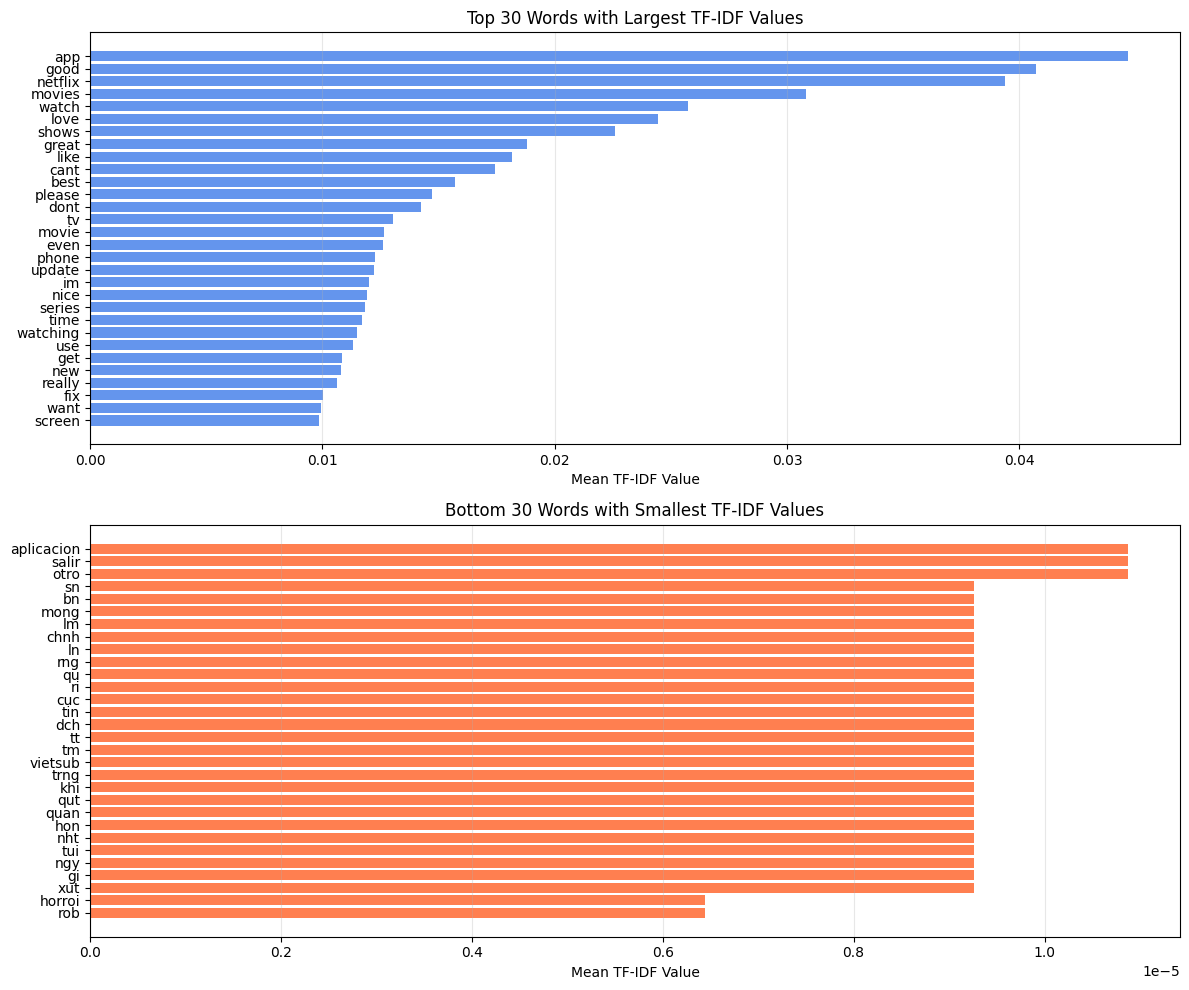

In [56]:
# Visualization of top and bottom 30 TF-IDF values
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top 30
top_30_sorted = top_30_tfidf.sort_values('mean_tfidf', ascending=True)
axes[0].barh(top_30_sorted['word'], top_30_sorted['mean_tfidf'], color='cornflowerblue')
axes[0].set_xlabel('Mean TF-IDF Value')
axes[0].set_title('Top 30 Words with Largest TF-IDF Values')
axes[0].grid(axis='x', alpha=0.3)

# Bottom 30
axes[1].barh(bottom_30_tfidf['word'], bottom_30_tfidf['mean_tfidf'], color='coral')
axes[1].set_xlabel('Mean TF-IDF Value')
axes[1].set_title('Bottom 30 Words with Smallest TF-IDF Values')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
# creating dataframe with the tf_idf scores for each word for each document
A = pd.DataFrame(tfidf_matrix.toarray(), columns = tfidf_vectorizer.get_feature_names_out())
A.head()

,aa,aaa,aacha,aadmi,aaj,aaja,aakh,aana,aap,aapiam,...,zim,zipcode,zkia,zobies,zoe,zones,zoom,zoomed,zoro,zur
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We'll be using a linear support vector machine to predict the ratings each user gave the app using the tf_idf scores. We first
split our data, stratifying on the outcome in order to ensure an equal proportion of the five potential
ratings across the training and testing sets. We then drop the columns with zero variance since they do not have any predictive power. 

In [58]:
X_train, X_test, y_train, y_test = train_test_split(A, sample['score'], 
                                                    test_size = 0.25, stratify = sample['score'], random_state = 42)

In [59]:
# dropping zero variance columns
selector = VarianceThreshold()
X_train = selector.fit_transform(X_train)
X_test = selector.transform(X_test)

Now we'll fit our SVM and evaluate the outcome.

In [60]:
svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [61]:
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.6284


In [ ]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)
disp.plot(values_format="d", ax=ax)
ax.set_title("Confusion Matrix for Linear SVM")
ax.set_xlabel("Predicted Score")
ax.set_ylabel("Actual Score")
plt.tight_layout()
plt.savefig("figure_confusion_matrix_linear_svm.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
actual_counts = pd.Series(y_test).value_counts().sort_index()
predicted_counts = pd.Series(y_pred).value_counts().sort_index()
distribution_df = pd.DataFrame({
    "Actual": actual_counts,
    "Predicted": predicted_counts
}).fillna(0)

x = np.arange(len(distribution_df.index))
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(
    x - width / 2,
    distribution_df["Actual"],
    width,
    label="Actual"
)
plt.bar(
    x + width / 2,
    distribution_df["Predicted"],
    width,
    label="Predicted"
)

plt.xticks(x, distribution_df.index.astype(str))
plt.xlabel("Rating Score")
plt.ylabel("Number of Reviews")
plt.title("Actual vs Predicted Rating Distribution")
plt.legend()

plt.tight_layout()
plt.savefig("figure_actual_vs_predicted_distribution.png", dpi=300, bbox_inches="tight")
plt.show()